<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/16_1_%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BD%D0%B0_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

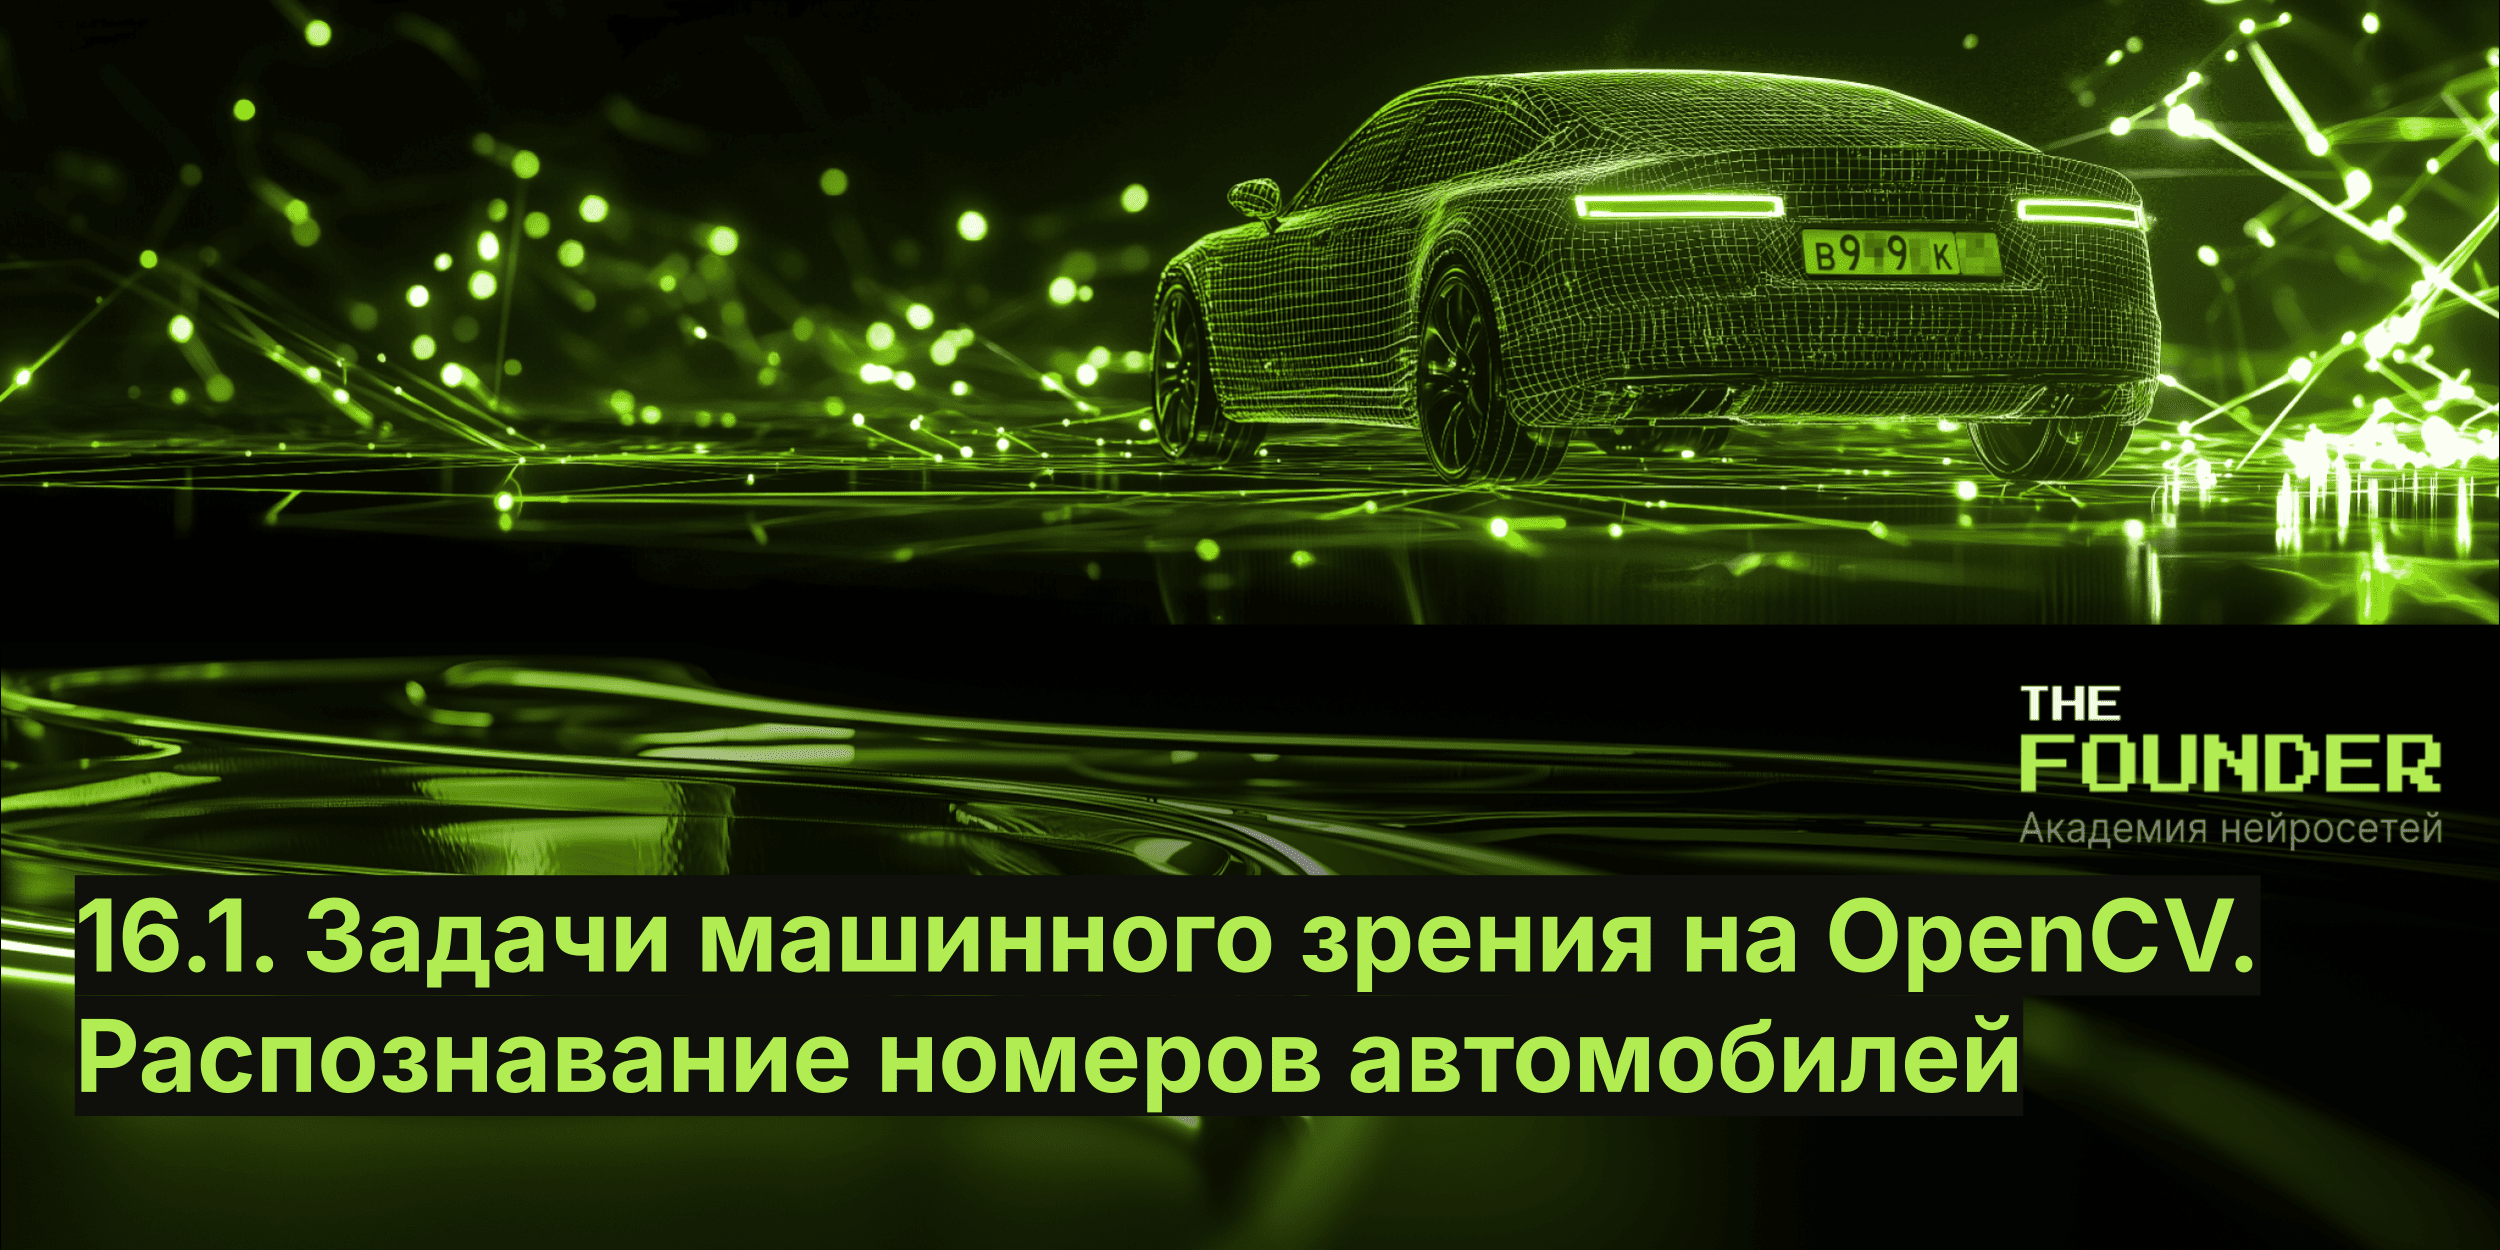

**Навигация по уроку**

1. Задачи машинного зрения на OpenCV. Распознавание номеров автомобилей
2. [OpenCV. Распознавание лиц (практика)](https://colab.research.google.com/drive/1GwMZ8BAjtdKBDA5S0lAX1OPMFmIaYhqL)
3. [Домашняя работа](https://colab.research.google.com/drive/1ROlDnTWg80AlhffK5duVa1vuHrM9Q8HQ)

Данным уроком мы открываем знакомство с библиотеками и фреймворками для задач машинного обучения. И начнем знакомство с одной из самых популярных библиотек компьютерного зрения OpenCV.

Библиотека OpenCV (Open Source Computer Vision Library) — одна из самых популярных библиотек для приложений по компьютерному зрению. OpenCV-Python —
это Python-версия интерфейса для OpenCV. Наличие кода на C/C++ в бэкенде гарантирует быструю работу приложений, а Python-обертка обеспечивает легкость
настройки и развертывания. Благодаря этому OpenCV-Python является отличным
решением для высоконагруженных вычислительных программ по компьютерному
зрению. В эту библиотеку с открытым исходным кодом входят более 2500 алгоритмов, среди которых есть как классические, так и современные алгоритмы для
компьютерного зрения и машинного обучения.

При работе с этой библиотекой есть несколько тонкостей. Общепринятое ее название — OpenCV. Но для ее установки мы используем имя `opencv-python`:



In [ ]:
!pip install opencv-python

А импорт библиотеки в свой проект мы осуществляем по другому имени:

In [ ]:
import cv2

## Предобученные модели OpenCV

Для того чтобы нейронная сеть смогла распознавать объекты в изображениях,
в видеофайлах и видеопотоках, ее нужно этому обучить. Однако для библиотеки
OpenCV имеется набор уже обученных классификаторов, которые можно использовать в собственных приложениях. Это классификаторы на основе каскадов Хаара.
Каскад Хаара — способ обнаружения объектов на изображении, основанный на
машинном обучении. Обученный каскад Хаара, принимая на вход изображение, определяет, есть ли на нем искомый объект, т. е. выполняет задачу классификации,
разделяя входные данные на два класса: есть искомый объект, нет искомого объекта. Собственно, сам алгоритм работы сводится к тому, что определяются признаки Хаара. Это, по сути, метод обнаружения объектов, используемый для определения местоположения объектов на изображениях. Алгоритм обучается на большом количестве положительных и отрицательных образцов: положительные образцы - это изображения, которые содержат интересующий объект, а отрицательные образцы - это изображения, которые содержат что угодно, кроме искомого объекта.

Скачать каскады можно по адресу: https://github.com/opencv/opencv/tree/master/data/haarcascades

Доступны следующие каскады:

<table>
<tr><th>Файл</th><th>Распознаваемые объекты</th></tr>
<tr><td>haarcascade_eye.xml</td><td>Глаза</td></tr>
<tr><td>haarcascade_eye_tree_eyeglasses.xml</td><td>Глаза в очках</td></tr>
<tr><td>haarcascade_frontalcatface.xml</td><td>Фронтальная кошачья морда</td></tr>
<tr><td>haarcascade_frontalcatface_extended.xml</td><td>Фронтальная кошачья морда</td></tr>
<tr><td>haarcascade_frontalface_alt.xml</td><td>Фронтальное лицо</td></tr>
<tr><td>haarcascade_frontalface_alt2.xml</td><td>Фронтальное лицо 2</td></tr>
<tr><td>haarcascade_frontalface_alt_tree.xml</td><td>Фронтальное лицо каскад</td></tr>
<tr><td>haarcascade_frontalface_default.xml</td><td>Фронтальное лицо</td></tr>
<tr><td>haarcascade_fullbody.xml</td><td>Фронтальное тело</td></tr>
<tr><td>haarcascade_lefteye_2splits.xml</td><td>Левый глаз</td></tr>
<tr><td>haarcascade_licence_plate_rus_16stages.xml</td><td>Российские номерные знаки</td></tr>
<tr><td>haarcascadejowerbody.xml</td><td>Нижняя часть тела</td></tr>
<tr><td>haarcascade_profileface.xml</td><td>Профиль лица</td></tr>
<tr><td>haarcascade_righteye_2splits.xml</td><td>Правый глаз</td></tr>
<tr><td>haarcascade_russian_plate_number.xml</td><td>Российские номерные знаки</td></tr>
<tr><td>haarcascade_smile.xml</td><td>Улыбка</td></tr>
<tr><td>haarcascade_upperbody.xml</td><td>Верхняя часть тела</td></tr>
</table>

Если вы работаете с библиотекой OpenCV, то скачивать каскады Хаара не обязательно, т. к. они уже включены в состав библиотеки. Их можно просто подключать с использованием следующей инструкции:


In [ ]:
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

С помощью каскадов Хаара можно решать большой класс задач компьютерного зрения, например, сегментации изображений. Рассмотрим несколько примеров применения.

## Распознавание номеров автомобилей

Приложения, обеспечивающие распознавание автомобильных номеров, являются
одними из самых востребованных программных продуктов, применяемых в транспортной отрасли. Они используются органами ГИБДД, на автоматизированных
парковках, в системах обеспечения доступа на склады и в коттеджные поселки, организациями, обеспечивающими дорожный сервис, мониторинг дорожного трафика
и т. п. В библиотеку OpenCV включены каскады Хаара для распознавания номеров
автомобилей — как российских номеров, так и номеров различных европейских
стран.

В качестве примера распознаем госномер на изображениях автомобилей с российскими номерами.


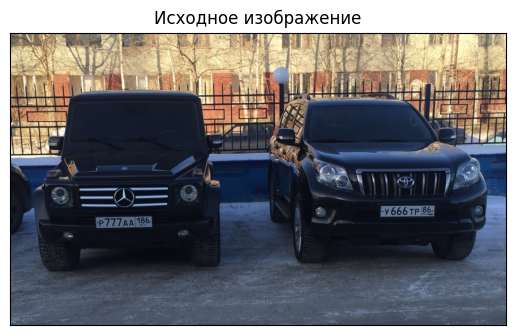

In [ ]:
import cv2
import gdown
from matplotlib import pyplot
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

gdown.download('https://storage.yandexcloud.net/academy.ai/number_2_car.jpg', None, quiet=True)

# Загрузка изображения
img_bgr = cv2.imread('./number_2_car.jpg')

# Изображения в OpenCV загружаются в формате BGR, а для отображения стоит менять на RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# показать загруженное изображение
pyplot.imshow(img_rgb)
pyplot.title('Исходное изображение'),
pyplot.xticks([])
pyplot.yticks([])
pyplot.show()



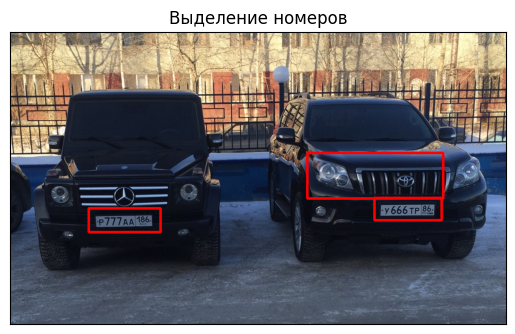

In [ ]:

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')
# Выполнение распознавания объектов
bboxes = classifier.detectMultiScale(img_rgb)
# формирование прямоугольника вокруг каждого обнаруженного объекта

for box in bboxes:
    # формирование координат
    x, у, width, height = box
    x2, y2 = x + width, у + height
    # рисование прямоугольников
    cv2.rectangle(img_rgb, (x, у), (x2, y2), (255, 0, 0), 3)

# показать изображение с выделенными номерами
pyplot.imshow(img_rgb)
pyplot.title('Выделение номеров'),
pyplot.xticks([])
pyplot.yticks([])
pyplot.show()

Как мы видим нейронка распознала лишний прямоугольник.

Данная проблема решается следующим простым алгоритмом:

1. Преобразовать исходное изображение в черно-белый формат
2. Преобразовать черно-белое изображение пороговой обработкой
для упрощения нахождения контуров
3. Найти контуры изображения
4. Для каждого найденного контура выполнить процедуру
преобразования в текст
5. Отсечь все «мусорные» тексты

Также мы распознаем цифры на номерах с помощью библиотеки EasyOCR.

In [ ]:
!pip install easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 54.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 27.3 MB/s eta 0:00:00


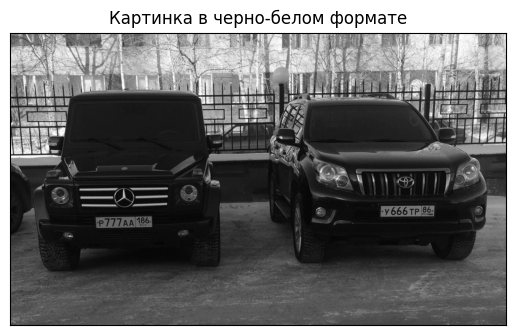

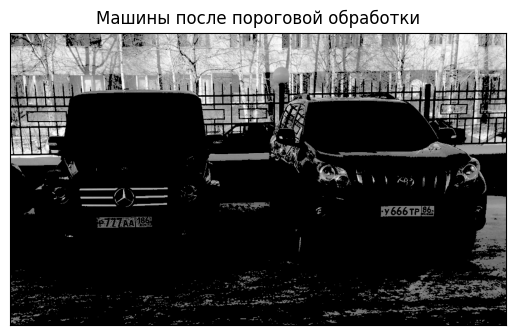

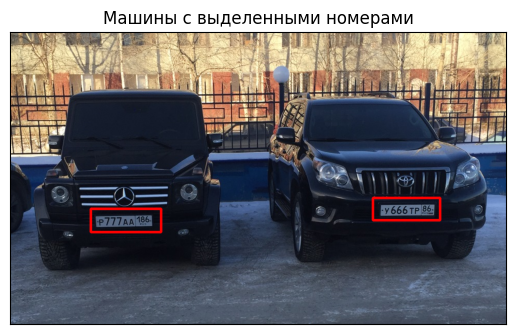

In [ ]:
import cv2
import easyocr
import string



chars = set('0123456789') # создадим множество цифр для отсечения "мусорных" текстов

image = cv2.imread("./number_2_car.jpg", cv2.IMREAD_UNCHANGED)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # преобразовать изображение в черно-белое


# показать изображение
pyplot.imshow(image_gray, 'gray')
pyplot.title('Картинка в черно-белом формате'),
pyplot.xticks([])
pyplot.yticks([])
pyplot.show()

threshold = cv2.threshold(image_gray, 100, 200, cv2.THRESH_TOZERO)[1] # пороговая обработка для выделения контуров

car_number = [] # Список номеров автомобилей
car_number_image = [] # Список изображений с вырезанными номерами автомобилей

# показать обработанные изображения
pyplot.imshow(threshold, 'gray')
pyplot.title('Машины после пороговой обработки'),
pyplot.xticks([])
pyplot.yticks([])
pyplot.show()

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')
# Выполнение распознавания объектов
bboxes = classifier.detectMultiScale(threshold)
# формирование прямоугольника вокруг каждого обнаруженного объекта

for box in bboxes:
    # формирование координат
    border = 3
    x, у, width, height = box
    x2, y2 = x + width, у + height
    # рисование прямоугольников
    cv2.rectangle(image, (x, у), (x2, y2), (0, 0, 255), 3)

    img = image[у+3:y2-3, x+3:x2-3] # получим этот контур из исходного изображения, уберем рамку

    #Вырезанные номера автомобилей
    car_number_image.append(img)

# показать обработанные изображения
pyplot.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
pyplot.title('Машины с выделенными номерами'),
pyplot.xticks([])
pyplot.yticks([])
pyplot.show()


Номера собраны в массив:

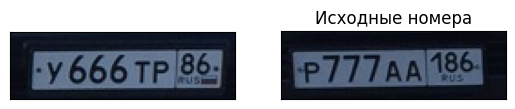

In [ ]:
# показать обработанные изображения

fig, ax = pyplot.subplots(1, len(car_number_image))

for i, img in enumerate(car_number_image):
  ax[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  ax[i].xaxis.set_ticks([])
  ax[i].yaxis.set_ticks([])
pyplot.title('Исходные номера'),

pyplot.show()

Распознаем номера с помощью EasyOCR:

In [ ]:
# Пытаемся распознать
reader = easyocr.Reader(['en'])
# Задаем справочник допустимых сиволов в номерах, упрощаем задачу для EasyOCR
ALLOW_STRING = 'HMABTCXOPEKY0123456789xopky'


for i, img in enumerate(car_number_image):
    # Запускаем распознавание, можно и на CPU, процесс быстрый
    result = reader.readtext(img, detail=0, paragraph=True, allowlist=ALLOW_STRING)[0] # преобразуем его в текст
    result = ''.join(result)
    if len(result) > 7 and any((c in chars) for c in result):
        # отсекая "мусорные" варианты, выведем распознанный номер в консоль
        car_number.append(result)

print()
print(f'Распознанные номера: {car_number}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
Распознанные номера: ['Y666TPBE', 'P7T7AA186']


### Преобразование изображения для улучшения оптического распознавания

Мы видим, что результат неудовлетворительный. Но его можно улучшить, проведя работу с вырезанными номерами.

Наиболее часто используются следующие преобразования для улучшения качества распознавания:
1. **Трансформация текста** (повороты, растягивание, сжатие). У нас номер не требует трансформации, поэтому проводить не будем.
2. **Морфологические преобразования** – это преобразования множества пикселей одного изображения с помощью множества пикселей другого – структурирующего элемента или ядра. Имеются два основных морфологических оператора – это эрозия и расширение. Применение этих операторов в различных комбинациях дает новые морфологические преобразования.
3. **Применение пороговых преобразований**. В процессе пороговой обработки изображения все значения интенсивности пикселей по очереди сравниваются с пороговым значением. Старое значение интенсивности пикселя удаляется, и в зависимости от того, больше или меньше интенсивность пикселя порогового значения, этому пикселю присваивается новое значение интенсивности. Если интенсивность пикселя больше порогового значения,
то новое значение интенсивности будет равно 255, если интенсивность пикселя меньше порогового значения, то новое значение интенсивности будет равно 0. В результате получим бинарное изображение. Мы применем черно-белую двоичную инверсию. То есть серые цвета с одной стороны порога будут белые, с другой черные, при этом будет произведена инверсия и мы получим негативное изображение.
4. **Изменение яркости и контрастности изображения**.



Морфологические преобразования – это преобразования множества пикселей одного изображения с помощью множества пикселей другого – структурирующего элемента или ядра. Имеются два основных морфологических оператора – это эрозия и расширение. Применение этих операторов в различных комбинациях дает новые морфологические преобразования: открытие, закрытие и т. д.

Дилатация увеличивает область изображения, расширяя его пиксели и тем самым способствуя объединению областей изображения, которые были разделены шумом:

```python
dilation = cv2.dilate(img, kernel)
```

* **img** - множество (наше изображение)
* **kernel** - ядро (матрица преобразования)

Операция эрозия, наоборот, ужимает (утончает) изображения.

Дилатация приводит к расширению изображения, эрозия к сжатию.
Первый аргумент функции эрозии – это массив основного множества, второй – это ядро:

```python
erosion = cv2.erode(img, kernel)
```

Мы попробуем применить дилатацию для избавления от шума на изображении, а эрозию - для утолщение букв и цифр номера. Морфологические преобразования чаще всего применяются после пороговых преобразований.

In [ ]:
car_number

['Y666TPBE', 'P7T7AA186']

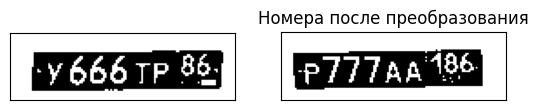

In [ ]:
import numpy as np

new_car_number = []

fig, ax = pyplot.subplots(1, len(car_number_image))
for i, img in enumerate(car_number_image):
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  contrast2 = cv2.convertScaleAbs(img, alpha=3, beta=10) # параметр alpha - коэффициент контрастности, beta - смещение яркости
  threshold = cv2.threshold(contrast2, 180, 200, cv2.THRESH_BINARY_INV)[1] # пороговая обработка для выделения контуров

  dilation = cv2.dilate(threshold, np.ones((3,3), np.uint8)) # дилатацию проводим с единичной матрицей

  erosion = cv2.erode(dilation, np.ones((2,2), np.uint8)) # размытие проводим с единичной матрицей

  new_car_number.append(threshold)
  ax[i].imshow(threshold, 'gray')
  ax[i].xaxis.set_ticks([])
  ax[i].yaxis.set_ticks([])
pyplot.title('Номера после преобразования'),

pyplot.show()

In [ ]:
for img in new_car_number:
    result = reader.readtext(img, detail=0, paragraph=False, allowlist=ALLOW_STRING)[0] # преобразуем его в текст
    print(result)

Y666TP86
P777AA186


Такие достаточно простые преобразования позволили получить 2 из 2-х правильно распознаных номера, не прибегая к дообучению моделей EasyOCR.

## Распознавание движущих машин в потоке

С помощью каскадов Хаара можно распознавать движущие машины по автостраде:

In [ ]:
from google.colab.patches import cv2_imshow
from IPython.display import clear_output, Image
import time
import cv2
import gdown
# Каскад Хаара для машин
gdown.download('https://storage.yandexcloud.net/academy.ai/haarcascade_cars.xml', None, quiet=True)


def cascad_play(name, sleep = 1/30):
    gdown.download(f'https://storage.yandexcloud.net/academy.ai/{name}', None, quiet=True)
    cap = cv2.VideoCapture(f'./{name}') # активация камеры
    car_cascade = cv2.CascadeClassifier('./haarcascade_cars.xml') # загрузка классификатора
    # цикл обработки кадров
    while cap.isOpened:
        ret, frames = cap.read() # читаем кадры из видео

        if not ret:
            break
        gray = cv2.cvtColor(frames, cv2.COLOR_BGR2GRAY) # оттенки серого

        # обнаруживаем автомобили
        cars = car_cascade.detectMultiScale(gray, 1.1, 1)
        # Нарисуем прямоугольник в найденном авто

        for (х, у, w, h) in cars:
            cv2.rectangle(frames, (х, у), (х + w, у + h), (0, 0, 255), 2)

        # Очищаем область вывода
        clear_output(wait=True)
        cv2_imshow(frames) # Отображаем фрейм
        #Задержка перед обновлением фрейма
        time.sleep(sleep)





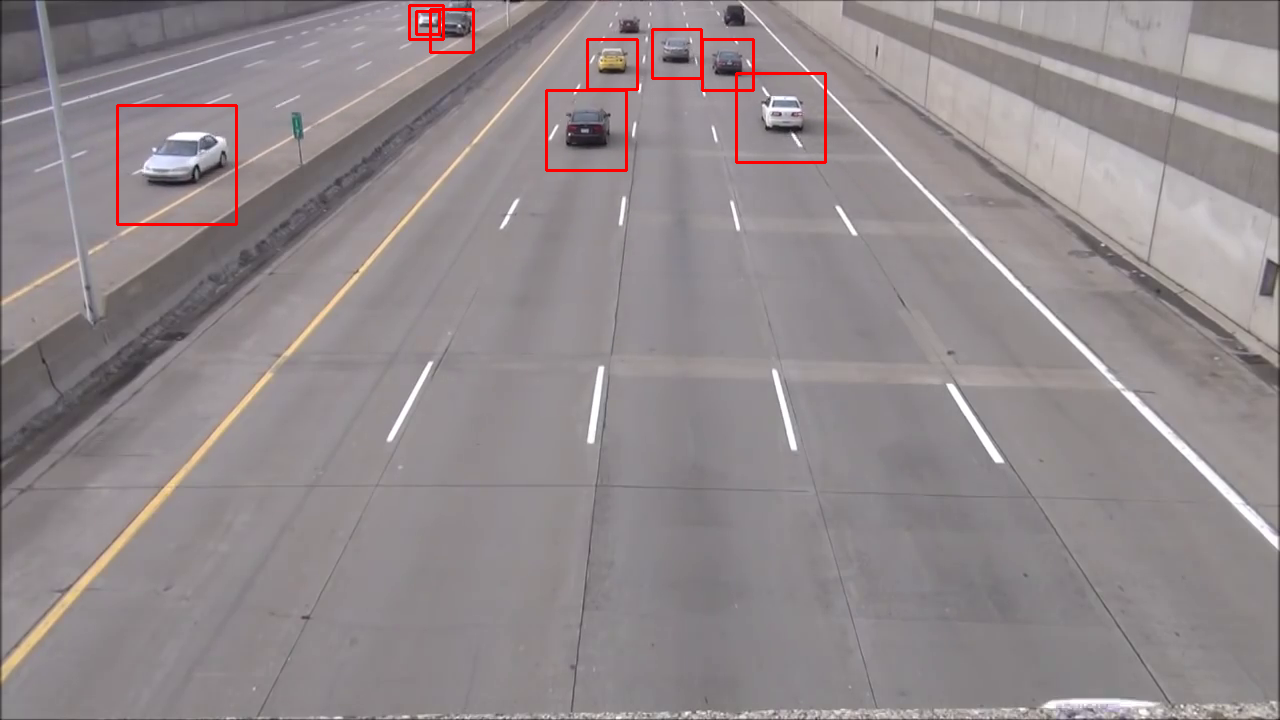

In [ ]:
cascad_play('cars.mp4')

На фоне дорожного полотна с большим числом движущих машин, каскады Хаара достаточно хорошо работают. Однако, если мы возьмем дорогу с более интересным окружающим ландшафтом, то заметим большое число ложных срабатываний:

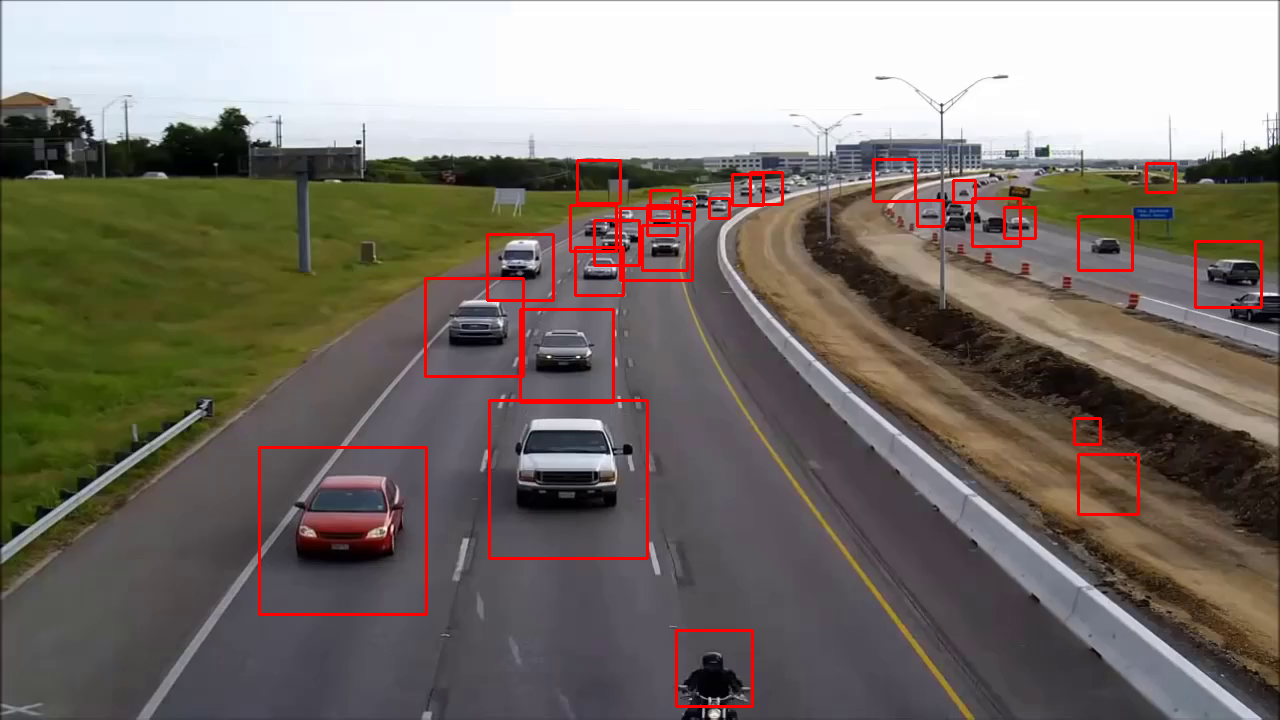

In [ ]:
cascad_play('traffic.mp4')

А если же мы возьмем нетипичную, заснеженную дорогу, то число ложных срабатываний вырастет в разы. Модель помечает мелкие элементы ландшафта как автомобиль:

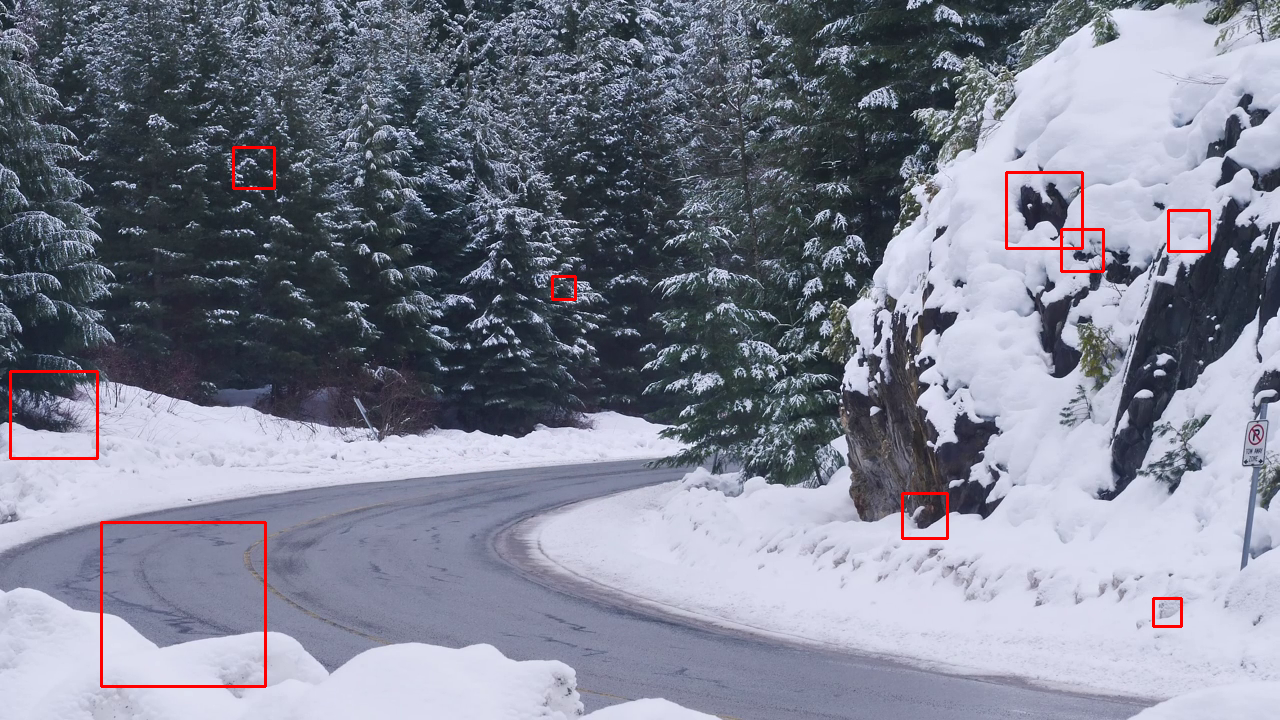

In [ ]:
cascad_play('snowy-forest-road.mp4')

Но нас это не должно сильно волновать. Вскоре когда мы дойдем до темы сегментации и детектировании объектов, вы познакомитесь с более продвинутыми методами компьютерного зрения. А сейчас мы перейдем к [следующей части урока](https://colab.research.google.com/drive/1GwMZ8BAjtdKBDA5S0lAX1OPMFmIaYhqL) и дадим каскадам Хаара еще один шанс: проявить себя в задачах по распознаванию лиц.